# 24. Cross-source transfer: RRUFF-only ↔ opXRD-only

Проверяется перенос двух актуальных source-only моделей на чужой real-домен:

- `RRUFF-only` -> opXRD;
- `opXRD-only` -> RRUFF.

In [ ]:
from pathlib import Path
import os
import subprocess
import sys

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError(f'Откройте ноутбук из корня DS_XRD_project. Текущий путь: {PROJECT_ROOT}')
os.chdir(PROJECT_ROOT)

def run_script(script_name, *args):
    command = [sys.executable, str(PROJECT_ROOT / 'src' / script_name), *map(str, args)]
    print('Running:', ' '.join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

print('Project root:', PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [ ]:
import json

required = [
    PROJECT_ROOT / 'checkpoints' / 'ft_rruff_only_with_rruff_sg_final.pt',
    PROJECT_ROOT / 'checkpoints' / 'ft_opxrd_only_final.pt',
    PROJECT_ROOT / 'outputs' / 'ft_rruff_only_with_rruff_sg_final_config.json',
    PROJECT_ROOT / 'outputs' / 'ft_opxrd_only_final_config.json',
    PROJECT_ROOT / 'data' / 'clean' / 'ft_pool_rruff_with_rruff_sg.parquet',
    PROJECT_ROOT / 'data' / 'clean' / 'ft_pool_opxrd.parquet',
]

missing = [path for path in required if not path.exists()]

if missing:
    raise FileNotFoundError('Не найдены обязательные артефакты:\n' + '\n'.join(map(str, missing)))

for name in ['ft_rruff_only_with_rruff_sg_final_config.json', 'ft_opxrd_only_final_config.json']:
    config = json.loads((PROJECT_ROOT / 'outputs' / name).read_text(encoding='utf-8'))

    print(name, '| threshold elements:', config['elements_threshold'], '| source:', config['source'])

ft_rruff_only_with_rruff_sg_final_config.json | threshold elements: 0.3 | source: RRUFF
ft_opxrd_only_final_config.json | threshold elements: 0.2 | source: opXRD


In [3]:
run_script('cross_source_transfer.py')

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\cross_source_transfer.py


## Таблица метрик

In [4]:
import pandas as pd

metrics_path = PROJECT_ROOT / 'outputs' / 'cross_source_transfer_metrics.csv'
metrics = pd.read_csv(metrics_path)
display_columns = [
    'model_to_target', 'n_rows', 'system_n', 'system_accuracy',
    'sg_n', 'sg_top1', 'sg_top5', 'elements_n', 'elements_micro_f1', 'elements_exact',
    'lattice_n', 'mae_a', 'mae_angle', 'mae_volume',
]
metrics[display_columns].round(4)

,model_to_target,n_rows,system_n,system_accuracy,sg_n,sg_top1,sg_top5,elements_n,elements_micro_f1,elements_exact,lattice_n,mae_a,mae_angle,mae_volume
0,RRUFF-only (SG-enriched) -> opXRD,2116,1355,0.4517,570,0.1579,0.2947,896,0.0214,0.0,1355,3.6864,7.3225,2006.3052
1,opXRD-only -> RRUFF,1359,1329,0.3988,1105,0.1819,0.4462,1357,0.1093,0.0,1298,3.2801,6.9497,586.0967


## Наглядное сравнение классификационных голов

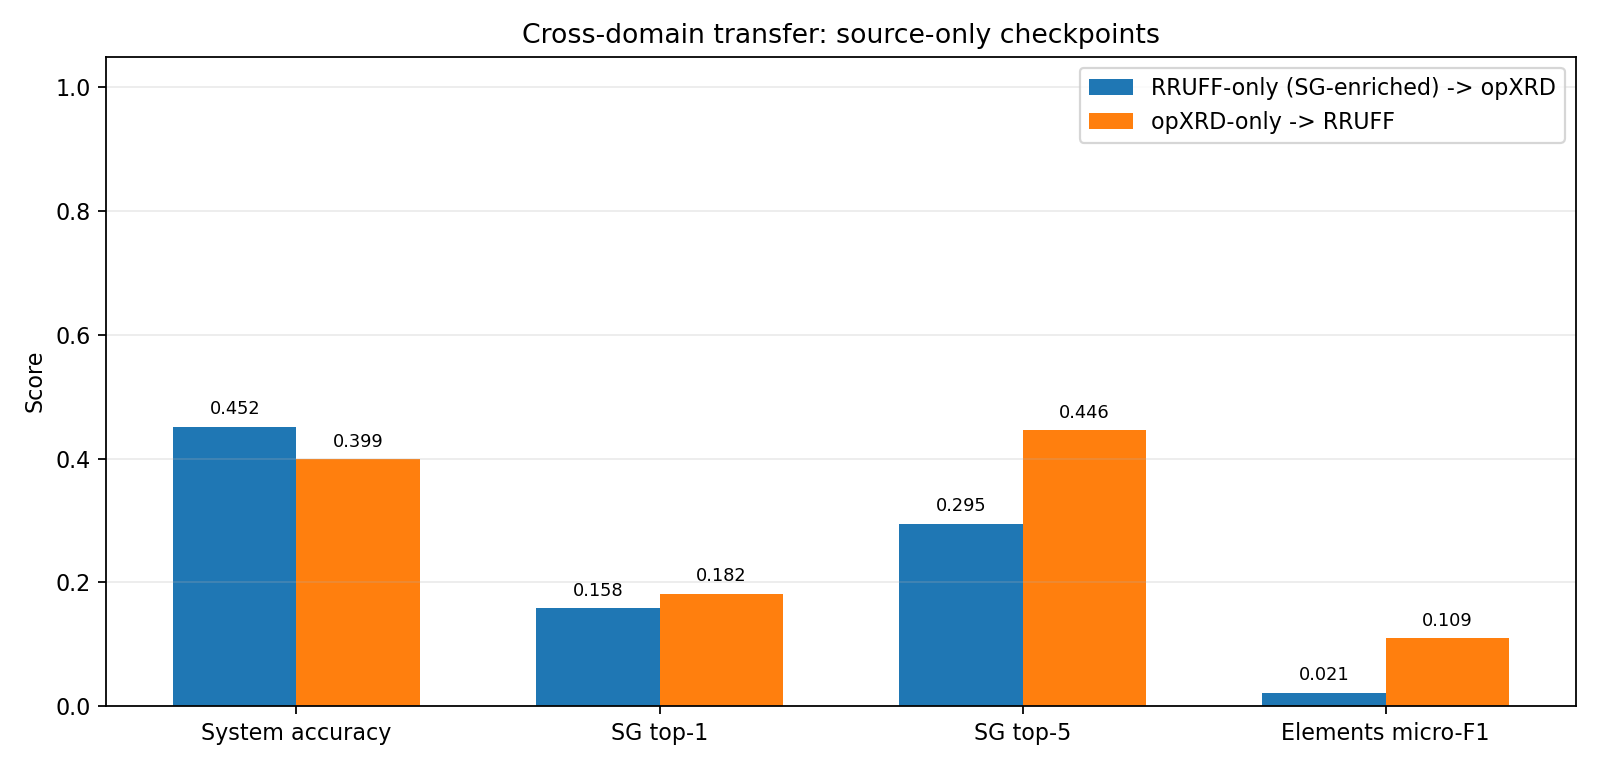

In [5]:
from IPython.display import Image, display

display(Image(filename=PROJECT_ROOT / 'outputs' / 'cross_source_transfer_metrics.png'))